In [1]:
# Librerie di base
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [2]:


# Percorso del file (adatta il nome al tuo file)
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/progetto/Dati/all_centroids_w31.csv"

# Caricamento dati
df = pd.read_csv(data_path)

# Mostra le prime righe
df.head()


,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,from_sea,type,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp
0,100431_1,BLSC,W,W1,1,M,ASY,Southern New England,Rhode Island,-70.211090,...,NaN,0,0,89,0,3.120704,0.041096,5.909524,0.066667,0.000749
1,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,WD,W,89,1,3.120704,0.279338,5.909524,0.066667,0.000749
2,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,W,SM,SM,89,1,3.120704,0.095890,5.909524,0.066667,0.000749
3,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,S,SM,SM,89,1,3.120704,0.271233,5.909524,0.066667,0.000749
4,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,F,MD,WM,89,1,3.120704,0.076712,5.909524,0.066667,0.000749


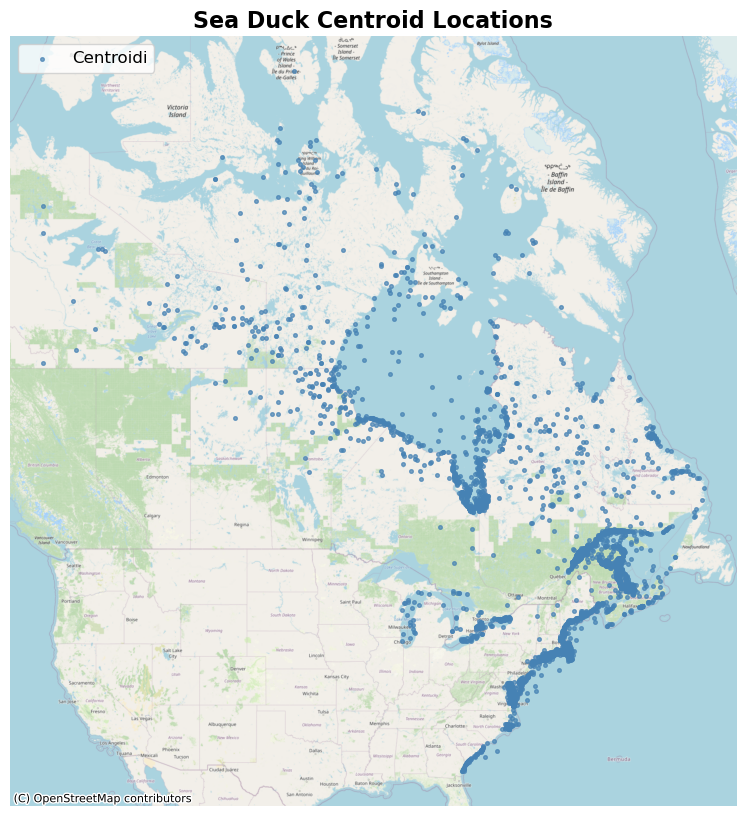

Numero di punti plottati: 3722


In [4]:
# 3️⃣ Plot migliorato
fig, ax = plt.subplots(figsize=(12, 10))

# Plot dei punti
gdf_proj.plot(
    ax=ax,
    color="steelblue",
    markersize=7,  # Dimensione dei punti
    alpha=0.7,
    label="Centroidi"  # Etichetta per la legenda
)

# 4️⃣ Aggiungiamo la mappa di sfondo
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,  # Mappa di sfondo
    zoom=5  # Regola il livello di zoom
)

# 5️⃣ Miglioriamo il layout
ax.set_title("Sea Duck Centroid Locations", fontsize=16, fontweight="bold")
ax.set_axis_off()  # Rimuove gli assi
ax.legend(fontsize=12, loc="upper left")  # Aggiunge la legenda

# Salva il grafico come immagine (opzionale)
plt.savefig("sea_duck_centroids.png", dpi=300, bbox_inches="tight")

plt.show()

print(f"Numero di punti plottati: {len(gdf_proj)}")

Unique 'season' values: ['W' 'S' 'F' 'B']
Counts by season:
 season
W    1179
F    1106
S     975
B     462
Name: count, dtype: int64


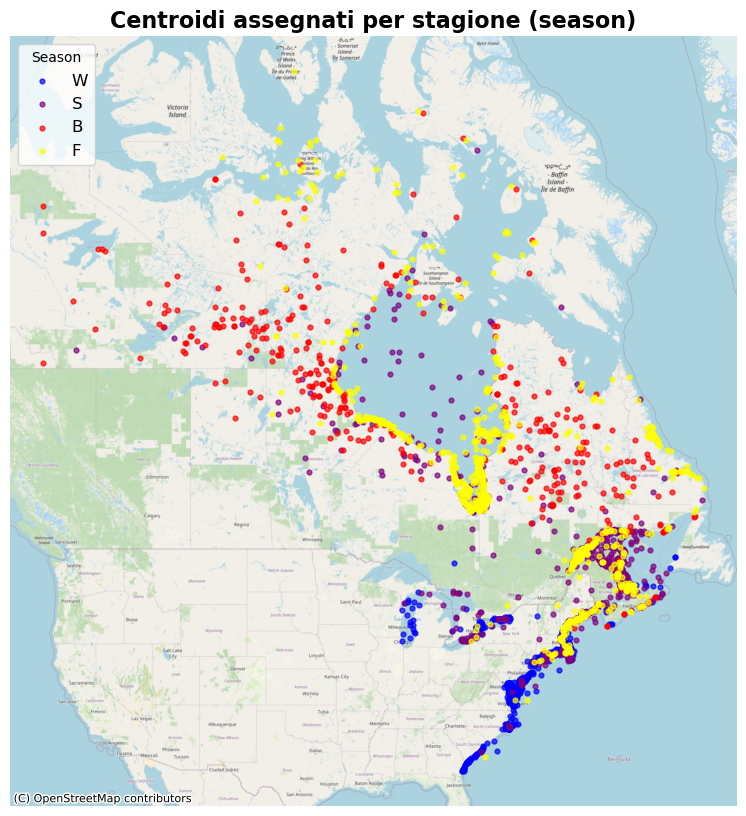

In [7]:
# Creiamo il GeoDataFrame (riconverti se necessario)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# Controllo rapidi sui valori unici (facoltativo ma utile)
print("Unique 'season' values:", gdf['season'].unique())
print("Counts by season:\n", gdf['season'].value_counts())

# Mappatura colori coerente con il paper
season_color = {
    'W': 'blue',   # winter
    'S': 'purple', # spring migration / spring staging
    'B': 'red',    # breeding
    'F': 'yellow'  # fall (post-breeding molt / fall staging)
}

# Convertiamo CRS per la basemap
gdf_proj = gdf.to_crs(epsg=3857)

# Plot migliorato
fig, ax = plt.subplots(figsize=(12, 10))

# Plot dei punti per ogni stagione
for code, color in season_color.items():
    subset = gdf_proj[gdf_proj['season'] == code]
    if len(subset):
        subset.plot(ax=ax, color=color, markersize=12, alpha=0.7, label=code)

# Aggiungiamo la mappa di sfondo
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,  # Mappa di sfondo
    zoom=5  # Regola il livello di zoom
)

# Miglioriamo il layout
ax.set_title("Centroidi assegnati per stagione (season)", fontsize=16, fontweight="bold")
ax.set_axis_off()  # Rimuove gli assi
ax.legend(title='Season', fontsize=12, loc="upper left")  # Aggiunge la legenda

# Salva il grafico come immagine (opzionale)
plt.savefig("season_centroids_map.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#DUNN INDEX
# Clustering-selection style "NbClust" in Python (complete-linkage, k in range)
# Richiede: pandas, numpy, scikit-learn, scipy, matplotlib
# Assumi df già caricato con colonne 'lon' e 'lat'

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from collections import Counter

# ---- utilità: Dunn index implementation (min intercluster dist / max intracluster dist)
def dunn_index(X, labels):
    # X: (n_samples, n_features), labels: array-like
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    # pairwise distances
    D = squareform(pdist(X))
    # intra-cluster max distance (diameter)
    max_intra = 0.0
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        if len(idx) <= 1:
            continue
        intra = D[np.ix_(idx, idx)]
        maxd = np.max(intra)
        if maxd > max_intra:
            max_intra = maxd
    # inter-cluster min distance
    min_inter = np.inf
    for i, li in enumerate(unique_labels):
        for j, lj in enumerate(unique_labels):
            if lj <= li: 
                continue
            idx_i = np.where(labels == li)[0]
            idx_j = np.where(labels == lj)[0]
            if len(idx_i)==0 or len(idx_j)==0:
                continue
            inter = D[np.ix_(idx_i, idx_j)]
            mind = np.min(inter)
            if mind < min_inter:
                min_inter = mind
    if max_intra == 0:
        return np.nan
    return min_inter / max_intra



# ---- funzione principale che prova una griglia di k e restituisce i risultati
def nbclust_like(df_coords, k_min=20, k_max=50, linkage='complete', metrics=None, random_state=42):
    """
    df_coords: DataFrame o array-like con colonne ['lon','lat']
    returns: dict con scores per k e il k scelto (majority voting)
    """
    X = np.array(df_coords[['lon','lat']])
    # standardizza le coordinate (NbClust usa le distanze geografiche; scaling aiuta)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    
    Ks = list(range(k_min, k_max+1))
    results = {k: {} for k in Ks}
    
    for k in Ks:
        # Agglomerative clustering, complete linkage
        cl = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = cl.fit_predict(Xs)
        # metriche
        # Silhouette score (max)
        try:
            sil = silhouette_score(Xs, labels)
        except Exception:
            sil = np.nan
        # Davies-Bouldin (min)
        try:
            db = davies_bouldin_score(Xs, labels)
        except Exception:
            db = np.nan
        # Calinski-Harabasz (max)
        try:
            ch = calinski_harabasz_score(Xs, labels)
        except Exception:
            ch = np.nan
        # Dunn (max)
        try:
            dun = dunn_index(Xs, labels)
        except Exception:
            dun = np.nan
        # custom D-index (max) similar to paper's D-index notion
        try:
            Dcust = custom_D_index(Xs, labels)
        except Exception:
            Dcust = np.nan
        
        results[k]['labels'] = labels
        results[k]['silhouette'] = sil
        results[k]['davies_bouldin'] = db
        results[k]['calinski'] = ch
        results[k]['dunn'] = dun
        results[k]['Dcust'] = Dcust
    
    # Per ogni indice, troviamo il k ottimale (silhouette: max, davies: min, calinski max, dunn max, Dcust max)
    picks = []
    # silhouette: maximize
    sil_vals = {k: results[k]['silhouette'] for k in Ks}
    k_sil = max(sil_vals, key=lambda k: sil_vals[k] if not np.isnan(sil_vals[k]) else -np.inf)
    picks.append(('silhouette', k_sil))
    # davies-bouldin: minimize
    db_vals = {k: results[k]['davies_bouldin'] for k in Ks}
    k_db = min(db_vals, key=lambda k: db_vals[k] if not np.isnan(db_vals[k]) else np.inf)
    picks.append(('davies_bouldin', k_db))
    # calinski: maximize
    ch_vals = {k: results[k]['calinski'] for k in Ks}
    k_ch = max(ch_vals, key=lambda k: ch_vals[k] if not np.isnan(ch_vals[k]) else -np.inf)
    picks.append(('calinski', k_ch))
    # dunn: maximize
    dun_vals = {k: results[k]['dunn'] for k in Ks}
    k_dun = max(dun_vals, key=lambda k: dun_vals[k] if not np.isnan(dun_vals[k]) else -np.inf)
    picks.append(('dunn', k_dun))
    # Dcust: maximize
    Dc_vals = {k: results[k]['Dcust'] for k in Ks}
    k_Dc = max(Dc_vals, key=lambda k: Dc_vals[k] if not np.isnan(Dc_vals[k]) else -np.inf)
    picks.append(('Dcust', k_Dc))
    
    # majority voting
    votes = [p[1] for p in picks]
    counts = Counter(votes)
    # best k by majority. if tie, choose smallest k among ties (or you can choose median)
    best_k, best_count = sorted(counts.items(), key=lambda x: (-x[1], x[0]))[0]
    
    summary = {
        'results': results,
        'picks': picks,
        'votes': counts,
        'best_k': best_k,
        'best_count': best_count,
        'Ks': Ks
    }
    return summary

# ---- ESEMPIO D'USO con il tuo df (usa df[['lon','lat']])
summary = nbclust_like(df[['lon','lat']], k_min=20, k_max=50, linkage='complete')

# ---- plot delle metriche vs k
Ks = summary['Ks']
sil = [summary['results'][k]['silhouette'] for k in Ks]
db = [summary['results'][k]['davies_bouldin'] for k in Ks]
ch = [summary['results'][k]['calinski'] for k in Ks]
dun = [summary['results'][k]['dunn'] for k in Ks]
Dcust = [summary['results'][k]['Dcust'] for k in Ks]

plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.plot(Ks, sil, label='Silhouette (max)')
plt.plot(Ks, ch, label='Calinski (max)')
plt.plot(Ks, Dcust, label='Custom D (max)')
plt.ylabel('score')
plt.legend()
plt.subplot(2,1,2)
plt.plot(Ks, db, label='Davies-Bouldin (min)')
plt.plot(Ks, dun, label='Dunn (max)')
plt.xlabel('k')
plt.ylabel('score')
plt.legend()
plt.suptitle('Validation indices across k')
plt.show()

# ---- plot voti (histogram)
import seaborn as sns
vote_items = list(summary['votes'].items())
vote_items = sorted(vote_items, key=lambda x: x[0])
ks_plot = [ki for ki, _ in vote_items]
counts_plot = [ct for _, ct in vote_items]

plt.figure(figsize=(10,4))
sns.barplot(x=ks_plot, y=counts_plot)
plt.xlabel('k')
plt.ylabel('votes (number of indices choosing that k)')
plt.title('Majority voting across indices')
plt.show()

# ---- ottieni labels per best k e aggiungile a df
best_k = summary['best_k']
labels_best = summary['results'][best_k]['labels']
df['cluster_nbclust'] = labels_best

# salva i nodi medi per cluster
nodes = df.groupby('cluster_nbclust')[['lon','lat']].mean().reset_index()
nodes.to_csv('nodes_nbclust.csv', index=False)

print("Recommended k by majority vote:", best_k)
print("Individual picks per metric:", summary['picks'])
print("Vote counts (k: votes):", summary['votes'])
